In [1]:
import ast
import sys
from pathlib import Path
import random
import pandas as pd
from datasets import load_dataset

c:\Users\ADMIN\miniforge3\envs\dnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.features import RAGPrototypeMatcher

In [3]:
# Mapping từ text gốc trong dataset sang item number chuẩn PHQ-9
PHQ_TO_ITEM = {
    "Little-interest-or-pleasure-in-doing": 1,
    "Feeling-down-depressed-or-hopeless": 2,
    "Trouble-falling-or-staying-asleep-or-sleeping-too-much": 3,
    "Feeling-tired-or-having-little-energy": 4,
    "Poor-appetite-or-overeating": 5,
    "Feeling-bad-about-yourself-or-that-you-are-a-failure-or-have-let-yourself-or-your-family-down": 6,
    "Trouble-concentrating-on-things-such-as-reading-the-newspaper-or-watching-television": 7,
    "Moving-or-speaking-so-slowly-that-other-people-could-have-noticed-Or-the-opposite-being-so-fidgety-or-restless-that-you-have-been-moving-around-a-lot-more-than-usual": 8,
    "Thoughts-that-you-would-be-better-off-dead-or-of-hurting-yourself-in-some-way": 9,
}

# Trọng số lâm sàng cho từng item PHQ-9
WEIGHTS = {
    1: 0.93,   # Item 1 - Anhedonia
    2: 1.00,   # Item 2 - Depressed mood (cao nhất)
    3: 0.86,   # Item 3 - Sleep
    4: 0.92,   # Item 4 - Fatigue (cao thứ 2)
    5: 0.86,   # Item 5 - Appetite
    6: 0.99,   # Item 6 - Worthlessness 
    7: 0.87,   # Item 7 - Concentration
    8: 0.63,   # Item 8 - Psychomotor (thấp nhất)
    9: 0.96,   # Item 9 - Suicidal (cảnh báo đặc biệt)
}

WEIGHTS_WITH_PHQ = {
    "Little-interest-or-pleasure-in-doing": 0.93,
    "Feeling-down-depressed-or-hopeless": 1.00,
    "Trouble-falling-or-staying-asleep-or-sleeping-too-much": 0.86,
    "Feeling-tired-or-having-little-energy": 0.99,
    "Poor-appetite-or-overeating": 0.86,
    "Feeling-bad-about-yourself-or-that-you-are-a-failure-or-have-let-yourself-or-your-family-down": 0.92,
    "Trouble-concentrating-on-things-such-as-reading-the-newspaper-or-watching-television": 0.87,
    "Moving-or-speaking-so-slowly-that-other-people-could-have-noticed-Or-the-opposite-being-so-fidgety-or-restless-that-you-have-been-moving-around-a-lot-more-than-usual": 0.63,
    "Thoughts-that-you-would-be-better-off-dead-or-of-hurting-yourself-in-some-way": 0.96,
}

# Mapping mức độ trầm cảm sang nhãn số
SEVERITY_MAPPING = {
    "Minimal": 0,
    "Mild": 1,
    "Moderate": 2,
    "Moderately Severe": 3,
    "Severe": 4,
}

Bộ trọng số sử dụng tham khảo từ https://www.sciencedirect.com/science/article/abs/pii/S0165032725025716

Bài báo trước đó thực hiện đánh giá nhanh với phq-2, tập trung vào 2 câu hỏi:
- Feeling-down-depressed-or-hopeless
- Feeling-tired-or-having-little-energy \
Meta-analysis trên 40 nghiên cứu với gần 27.000 bệnh nhân cho thấy 
- PHQ-2 có recall cao `89.3%` hơn PHQ-9 `81.3%`, tuy có specificity thấp hơn PHQ-9 `85.3%` khi chỉ có `75.9%`
Trong đó dặc biệt quan tâm 2 q: `Anhedonia` và `Depression mood` 

Trong bài báo này, tác giả đề xuất cải tiến với PHQ-2W dựa trên nghiên cứu của `Malgaroli et al. (2021)`, `Liang et al. (2023)` quan tâm đến 2 q: `Fatigue` và `Depression mood`

7 item khác thì ko nhớ lấy từ đâu ...

In [4]:
def preprocess_phq9_data(
    dataset_name: str = "darssanle/PHQ-9-Initial-Collection",
    split: str = "train",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Thực hiện toàn bộ pipeline xử lý dữ liệu PHQ-9.

    Các bước xử lý:
        1. Load dataset từ HuggingFace và chuyển thành DataFrame.
        2. Sắp xếp annotations theo thứ tự chuẩn PHQ-9 (Item 1 → 9).
        3. Tính điểm PHQ-9 có trọng số (weighted score).
        4. Trích xuất các cột điểm số riêng biệt.
        5. Phân loại mức độ trầm cảm (severity).
        6. Gán nhãn số (label) cho classification.

    Args:
        dataset_name: Tên dataset trên HuggingFace.
        split: Split của dataset cần load (mặc định "train").
        verbose: In thông tin xử lý ra console.

    Returns:
        pd.DataFrame với các cột:
            - post_title, post_text, annotations (gốc)
            - sorted_annotations: annotations đã sắp xếp theo Item 1→9
            - naive_phq9: điểm đếm đơn giản (số item 'yes')
            - weighted_phq9_raw: điểm có trọng số (chưa chuẩn hóa)
            - weighted_phq9_norm: điểm chuẩn hóa về thang 0-27
            - naive_severity: mức độ theo điểm naive
            - weighted_severity: mức độ theo điểm weighted
            - label: nhãn số (0-4) dựa trên weighted_severity
    """

    # ── STEP 1: Load dataset ─────────────────────────────────
    if verbose:
        print(f"Loading dataset '{dataset_name}' (split='{split}')...")

    dataset = load_dataset(dataset_name, split=split)
    df = pd.DataFrame(dataset)

    if verbose:
        print(f"  → Total samples: {len(df)}")
        print(f"  → Columns: {df.columns.tolist()}")

    # ── STEP 2: Sắp xếp annotations theo chuẩn PHQ-9 ────────
    def _reorder_annotations(annotations_list: list) -> list:
        """Chuyển annotations từ thứ tự ngẫu nhiên sang Item 1→9."""
        temp_dict = {}
        for question_text, answer in annotations_list:
            item_num = PHQ_TO_ITEM.get(question_text)
            if item_num is not None:
                temp_dict[item_num] = answer

        sorted_annotations = []
        for item_num in range(1, 10):
            try:
                sorted_annotations.append([item_num, temp_dict[item_num]])
            except KeyError:
                sorted_annotations.append([item_num, "no"])
                if verbose:
                    print(f"  ⚠ Missing item {item_num}, defaulting to 'no'")
        return sorted_annotations

    # df["sorted_annotations"] = df["annotations"].apply(_reorder_annotations)

    # ── STEP 3: Tính điểm PHQ-9 có trọng số ─────────────────
    def _calculate_weighted_score(annotations: list) -> dict:
        """Tính điểm PHQ-9 có trọng số từ annotations."""
        weighted_sum = 0.0
        max_weighted_sum = 9 # 9 câu phq
        naive_count = 0

        for question_text, answer in annotations:
            score = 1 if answer.lower() == "yes" else 0
            weight = WEIGHTS_WITH_PHQ.get(question_text, 1.0)
            weighted_sum += score * weight
            naive_count += score

        # Normalize về thang 0-27 để so sánh với lâm sàng
        normalized_score = (
            (weighted_sum / max_weighted_sum) * 27
            if max_weighted_sum > 0
            else 0
        )

        return {
            "raw_weighted_score": weighted_sum,
            "normalized_score": normalized_score,
            "naive_score": naive_count,
        }

    phq9_scores = df["annotations"].apply(_calculate_weighted_score)

    # ── STEP 4: Trích xuất thành các cột riêng ───────────────
    df["naive_phq9"] = phq9_scores.apply(lambda x: x["naive_score"])
    df["weighted_phq9_raw"] = phq9_scores.apply(lambda x: x["raw_weighted_score"])
    df["weighted_phq9_norm"] = phq9_scores.apply(lambda x: x["normalized_score"])

    # ── STEP 5: Phân loại mức độ trầm cảm ────────────────────
    def _classify_severity(score: float) -> str:
        if score <= 4:
            return "Minimal"
        elif score <= 9:
            return "Mild"
        elif score <= 14:
            return "Moderate"
        elif score <= 19:
            return "Moderately Severe"
        else:
            return "Severe"

    df["weighted_severity"] = df["weighted_phq9_norm"].apply(_classify_severity)

    # ── STEP 6: Gán nhãn số cho classification ────────────────
    df["label"] = df["weighted_severity"].map(SEVERITY_MAPPING)

    # ── Summary ──────────────────────────────────────────────
    if verbose:
        print("\n✅ Preprocessing complete!")
        print(f"  → Shape: {df.shape}")
        print("\n  Label distribution:")
        print(df["label"].value_counts().sort_index().to_string(header=False))
        print("\n  Sample results (first 5 rows):")
        print(
            df[["naive_phq9", "weighted_phq9_norm", "weighted_severity"]]
            .head()
            .to_string(index=True)
        )

    return df

In [5]:
def prototype_matcher(df:pd.DataFrame, query_text: str, top_max: int = 4, text_column='post_text', severity_column='weighted_severity'):
    matcher = RAGPrototypeMatcher(df, text_column=text_column, severity_column=severity_column)

    # query_text = df.iloc[idx]['post_text']
    # query_severity = df.iloc[idx]['weighted_severity']

    print(f"\nFINDING PROTOTYPES FOR QUERY")

    prototype_summary = matcher.get_prototype_summary(query_text, k=top_max+1)


    print("PROTOTYPE MATCHING RESULTS:")
    print(f"Average similarity: {prototype_summary['avg_similarity']:.3f}")
    print(f"Most common severity among prototypes: {prototype_summary['most_common_severity']}")
    print(f"Severity distribution: {prototype_summary['severity_distribution']}")
    print("\nTOP PROTOTYPES:")
    for p in prototype_summary['prototypes'][1:]:
        print(f"  {p['rank']}. Similarity={p['similarity']:.3f} | Severity={p['severity']} | PHQ-9={p['weighted_score']:.1f}")
        print(f"     Text: {p['text'][:100]}...")
    return prototype_summary['prototypes'][1:]

In [6]:
def row_to_binary(ann_str, text_list):
    # Parse chuỗi thành list
    if isinstance(ann_str, str):
        try:
            ann_list = ast.literal_eval(ann_str)
        except:
            ann_list = []
    else:
        ann_list = ann_str if isinstance(ann_str, list) else []
    
    # Mapping symptom -> 1/0
    mapping = {symptom: 1 if label == 'yes' else 0 for symptom, label in ann_list}
    # Lấy giá trị cho từng text trong text_list, mặc định 0
    return [mapping.get(text, 0) for text in text_list]

In [7]:
df = preprocess_phq9_data()
print(f"\nDataFrame columns: {df.columns.tolist()}")
text = df['post_text'][6]

top_match = prototype_matcher(df, query_text=text, top_max=5)

Loading dataset 'darssanle/PHQ-9-Initial-Collection' (split='train')...
  → Total samples: 2003
  → Columns: ['post_title', 'post_text', 'annotations']

✅ Preprocessing complete!
  → Shape: (2003, 8)

  Label distribution:
0    126
1    912
2    661
3    279
4     25

  Sample results (first 5 rows):
   naive_phq9  weighted_phq9_norm  weighted_severity
0           3                8.73               Mild
1           3                7.65               Mild
2           5               14.61  Moderately Severe
3           3                8.64               Mild
4           2                5.76               Mild

DataFrame columns: ['post_title', 'post_text', 'annotations', 'naive_phq9', 'weighted_phq9_raw', 'weighted_phq9_norm', 'weighted_severity', 'label']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 520.30it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đang xây dựng index cho 2003 prototypes...
Index sẵn sàng: 2003 vectors, dim=384

FINDING PROTOTYPES FOR QUERY
PROTOTYPE MATCHING RESULTS:
Average similarity: 0.695
Most common severity among prototypes: Mild
Severity distribution: {'Mild': 3, 'Minimal': 2, 'Moderate': 1}

TOP PROTOTYPES:
  2. Similarity=0.680 | Severity=Minimal | PHQ-9=3.0
     Text: Hi!  I believe my husband is depressed but not completely admitting to it yet.  We have been togethe...
  3. Similarity=0.644 | Severity=Mild | PHQ-9=7.6
     Text: I am going through a very difficult time after two miscarriages in the past couple of months and a r...
  4. Similarity=0.618 | Severity=Moderate | PHQ-9=11.4
     Text: My husband and I dearly love each other and he's going through a rough time right now. He's really d...
  5. Similarity=0.613 | Severity=Minimal | PHQ-9=3.0
     Text: So my boyfriend told me that he was in a bad place before he met me &amp; that nowadays (the entiret...
  6. Similarity=0.612 | Severity=Mild |

In [8]:
phq9_cols = list(PHQ_TO_ITEM.keys())
columns = phq9_cols + ["similarity"]

In [9]:
def prepare_joined_data(df, top_match, keep_columns, drop_columns='text', phq_cols=None, phq_to_item=None):

    # Xử lý top_match nếu là dict hoặc list
    if not isinstance(top_match, pd.DataFrame):
        top_match = pd.DataFrame(top_match)
    
    # Sử dụng giá trị mặc định nếu không được cung cấp
    if phq_cols is None:
        if phq_to_item is not None:
            phq_cols = list(phq_to_item.keys())
        else:
            # Nếu không có, thử lấy từ global hoặc báo lỗi
            try:
                phq_cols = list(PHQ_TO_ITEM.keys())
            except NameError:
                raise ValueError("phq_cols must be provided or PHQ_TO_ITEM must be defined globally")
    
    df_joined = df.merge(top_match, left_on='post_text', right_on='text', how='inner')
    
    df_joined = df_joined.drop(columns=[drop_columns])
    
    binary_data = df_joined['annotations'].apply(
        lambda x: row_to_binary(x, phq_cols)
    ).tolist()
    
    df_joined[phq_cols] = pd.DataFrame(binary_data, columns=phq_cols)
    
    df_joined = df_joined[keep_columns]
    
    return df_joined

def get_scores(df):
    scores = {}
    length = len(df)
    for col in phq9_cols:
        scores[col] = (df[col] * df["similarity"]).sum() / length * WEIGHTS_WITH_PHQ[col]

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return scores


In [10]:
df_joined = df_joined = prepare_joined_data(
    df=df,
    top_match=top_match,
    keep_columns=columns,
    drop_columns='text',
    phq_cols=phq9_cols,
)

In [11]:
for question, value in get_scores(df_joined):
    print(f"\nQuestion: {question}\nScore: {value:.2%}")


Question: Feeling-down-depressed-or-hopeless
Score: 63.36%

Question: Feeling-bad-about-yourself-or-that-you-are-a-failure-or-have-let-yourself-or-your-family-down
Score: 34.49%

Question: Thoughts-that-you-would-be-better-off-dead-or-of-hurting-yourself-in-some-way
Score: 11.76%

Question: Trouble-concentrating-on-things-such-as-reading-the-newspaper-or-watching-television
Score: 10.75%

Question: Moving-or-speaking-so-slowly-that-other-people-could-have-noticed-Or-the-opposite-being-so-fidgety-or-restless-that-you-have-been-moving-around-a-lot-more-than-usual
Score: 8.12%

Question: Little-interest-or-pleasure-in-doing
Score: 0.00%

Question: Trouble-falling-or-staying-asleep-or-sleeping-too-much
Score: 0.00%

Question: Feeling-tired-or-having-little-energy
Score: 0.00%

Question: Poor-appetite-or-overeating
Score: 0.00%


# Thử với test_sample

In [12]:
test_sample = {
    "text": "I wake up but nothing really changes. Getting out of bed feels impossible. My body is not sore but empty. Someone has drained all the fuel out of me. Even lifting my head from the pillow requires a mental conversation I am too exhausted to have. I stare at the ceiling. The idea of making breakfast or taking a shower feels like a mountain I have no strength to climb. The fatigue is not just physical. It is a heavy suffocating blanket over my brain. I sit in front of my laptop wanting to write but I can barely form a sentence. My mind is a blank gray fog. I shut the lid and curl up and lie there feeling tears come for no reason. Hopelessness whispers in my ear all day. It tells me this exhaustion is not a phase but a permanent state. How am I supposed to live like this. The future looks like a dark endless ocean. I do not see a way out. I just see more days of tired nothingness. People say it will get better but I cannot believe them. The pain feels permanent. I am stuck in traffic against my will running out of air with no exit in sight. I am tired of trying. I am tired of pretending to be okay just to make everyone else comfortable. Maybe this is just who I am now. A broken hollow person too exhausted to fix herself."
}

top_match = prototype_matcher(df, query_text=test_sample['text'], top_max=5)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 398.28it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đang xây dựng index cho 2003 prototypes...
Index sẵn sàng: 2003 vectors, dim=384

FINDING PROTOTYPES FOR QUERY
PROTOTYPE MATCHING RESULTS:
Average similarity: 0.700
Most common severity among prototypes: Moderately Severe
Severity distribution: {'Moderately Severe': 3, 'Moderate': 2, 'Mild': 1}

TOP PROTOTYPES:
  2. Similarity=0.708 | Severity=Moderate | PHQ-9=11.6
     Text: Before I get into the rest, I don't want to worry you. This isn't a suicide note or anything like th...
  3. Similarity=0.700 | Severity=Moderately Severe | PHQ-9=14.3
     Text: It seems like I can't do the work for my therapy. I droped out of colege, I have no friends, I feel ...
  4. Similarity=0.698 | Severity=Mild | PHQ-9=8.3
     Text: I don’t know what’s causing it. I’m just absolutely exhausted in the mornings to the point where it ...
  5. Similarity=0.692 | Severity=Moderately Severe | PHQ-9=14.3
     Text: And I can't do even that, since I seem to have crying block. That aside, I'm just really hopeless.

In [13]:
df_joined = prepare_joined_data(
    df=df,
    top_match=top_match,
    keep_columns=columns,
    drop_columns='text',
    phq_cols=phq9_cols,
)

for question, value in get_scores(df_joined):
    print(f"\nQuestion: {question}\nScore: {value:.2%}")


Question: Feeling-down-depressed-or-hopeless
Score: 69.54%

Question: Feeling-bad-about-yourself-or-that-you-are-a-failure-or-have-let-yourself-or-your-family-down
Score: 63.98%

Question: Feeling-tired-or-having-little-energy
Score: 55.03%

Question: Trouble-falling-or-staying-asleep-or-sleeping-too-much
Score: 35.74%

Question: Thoughts-that-you-would-be-better-off-dead-or-of-hurting-yourself-in-some-way
Score: 13.59%

Question: Trouble-concentrating-on-things-such-as-reading-the-newspaper-or-watching-television
Score: 12.04%

Question: Moving-or-speaking-so-slowly-that-other-people-could-have-noticed-Or-the-opposite-being-so-fidgety-or-restless-that-you-have-been-moving-around-a-lot-more-than-usual
Score: 8.57%

Question: Little-interest-or-pleasure-in-doing
Score: 0.00%

Question: Poor-appetite-or-overeating
Score: 0.00%


In [14]:
def weighted_phq9_classify(annotations: list) -> dict:
    """
    Tính điểm PHQ-9 có trọng số và phân loại mức độ trầm cảm.
    
    Parameters:
    -----------
    annotations : list of tuples
        Mỗi tuple là (question_text, score) với score là 0, 1, 2, hoặc 3
    
    Returns:
    --------
    dict : {
        "weighted_score": float,      # Tổng weighted (chưa normalize)
        "normalized_score": float,    # Normalized về thang 0-27
        "max_possible_score": float,  # Tổng trọng số tối đa (nếu tất cả là 3)
        "severity": str               # Mức độ trầm cảm
    }
    """
    # Tính tổng trọng số tối đa (nếu tất cả câu hỏi đều ở mức 3)
    max_weighted_score = 9
    
    # Tính tổng weighted score từ annotations
    weighted_score = 0.0
    for question_text, score in annotations:
        weight = WEIGHTS_WITH_PHQ.get(question_text, 1.0)
        weighted_score += score * weight
    
    # Normalize về thang 0-27
    if max_weighted_score > 0:
        normalized_score = (weighted_score / max_weighted_score) * 27
    else:
        normalized_score = 0
    
    # Phân loại mức độ
    if normalized_score <= 4:
        severity = "Minimal"
    elif normalized_score <= 9:
        severity = "Mild"
    elif normalized_score <= 14:
        severity = "Moderate"
    elif normalized_score <= 19:
        severity = "Moderately Severe"
    else:
        severity = "Severe"
    
    return {
        "weighted_score": weighted_score,
        "normalized_score": normalized_score,
        "max_possible_score": max_weighted_score,
        "severity": severity
    }

In [15]:
result = weighted_phq9_classify(get_scores(df_joined))

print(f"Weighted Score: {result['weighted_score']:.2f}")
print(f"Normalized Score: {result['normalized_score']:.2f} / 27")
print(f"Max Possible: {result['max_possible_score']:.2f}")
print(f"Severity: {result['severity']}")


Weighted Score: 2.43
Normalized Score: 7.28 / 27
Max Possible: 9.00
Severity: Mild


### Predict label với mentalbert

In [28]:
from transformers import pipeline

class CustomDepressionPipeline:
    def __init__(self, model_path: str):
        self.classifier = pipeline(
            "text-classification",
            model=model_path,
            tokenizer=model_path,
            device=0  # GPU
        )
        
        self.label_map = {
            'LABEL_0': 'Minimal',
            'LABEL_1': 'Mild',
            'LABEL_2': 'Moderate',
            'LABEL_3': 'Moderately Severe',
            'LABEL_4': 'Severe'
        }
    
    def predict(self, text: str) -> dict:
        raw_result = self.classifier(text)[0]
        
        return {
            "severity": self.label_map[raw_result['label']],
            "confidence": raw_result['score'],
            "raw_label": raw_result['label']
        }
    
    def predict_batch(self, texts: list) -> list:
        raw_results = self.classifier(texts)
        results = []
        for raw in raw_results:
            results.append({
                "severity": self.label_map[raw['label']],
                "confidence": raw['score'],
                "raw_label": raw['label']
            })
        return results

In [29]:
pipeline = CustomDepressionPipeline("./models_saved/mentalbert_phq9_finetuned")
result = pipeline.predict(test_sample['text'])
print(f"Severity: {result['severity']} | Confidence: {result['confidence']:.2%}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 454.32it/s, Materializing param=classifier.weight]                                      


Severity: Moderately Severe | Confidence: 48.47%


## Kết luận từ test_sample (`Những thông tin quan trọng cần hiển thị`)

### Mental Health Assessment Results

Tổng hợp các q và tỉ lệ đáp úng câu hỏi tương ứng:

| Symptom | Score |
|---------|-------|
| Feeling down, depressed, or hopeless | **69.54%** |
| Feeling bad about yourself, feeling like a failure, or having let yourself/family down | **63.98%** |
| Feeling tired or having little energy | **55.03%** |
| Trouble falling/staying asleep, or sleeping too much | **35.74%** |
| Thoughts that you would be better off dead, or hurting yourself | **13.59%** |
| Trouble concentrating (e.g., reading the newspaper or watching TV) | **12.04%** |
| Moving/speaking slowly, or being fidgety/restless | **8.57%** |
| Little interest or pleasure in doing things | **0.00%** |
| Poor appetite or overeating | **0.00%** |

---

### Diagnostic Results

####  `ragprototype_matcher` (weighted + similarity)
- **Depression Severity:** **Mild**
- **Total Score:** 7.28 / 27

####  `mentalBert`
- **Depression Severity:** **Moderately Severe**
- **Confidence:** 48.47%



# Ý tưởng chính khi thực thi feature:

1. Finetune mô hình Sử dụng dữ liệu: text + phq-score
    - Từ phq-score -> nhãn (`minimal`, `mild`, `moderate`, `severely` `moderate`, `severely`)
    - Finetune mentalbert (text + label)
 
2. Xây dựng hệ thống dự đoán tình trạng trầm cảm cho 1 text kết quả phq-9
 B1: RagPrototypeMatching thực hiện search `top-k` sample gần nhất (embeddings tạo bởi mentalbert) 
    - faiss search với IndexFlatIP, in-memory \
 B2: Lấy các phq-score mỗi `top-k` các mẫu tương đồng nhất \
 B3: Tính tỉ lệ cho mỗi phq bằng cách : 
$$
\text{Score}_c = \frac{\text{WEIGHTS\_WITH\_PHQ}_c}{k} \sum_{i=1}^{k} \left( \text{similarity}_i \times r_i \right)
$$

Trong đó $\text{Score}_c$ đại diện cho tỉ lệ câu hỏi phq đáng được quan tâm đối với đối tượng
3. Kết luận
 - $\text{Score}_c$ cho biết tỉ lệ mà người đặt câu hỏi có dấu hiệu đáp ứng cho câu hỏi đó => Có $\text{Score}_c$ => label
 - Mô hình `mentalbert` => label 
 - Show kết quả: Bao gồm $\text{Score}_c$ và 2 label

# Kết quả finetune mô hình:

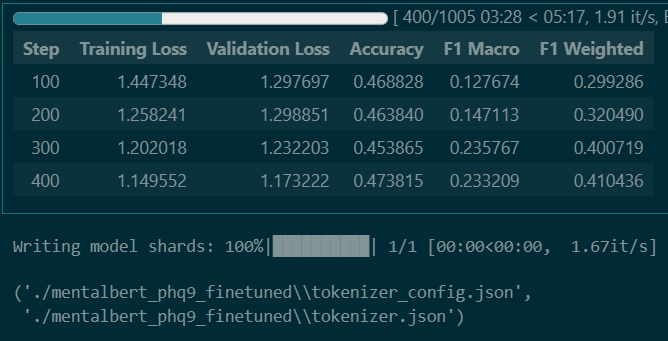

Lưu ý:
 - macro f1: trung bình cộng f1 score mỗi class
 - weight f1: trung bình có trọng số theo số mẫu mỗi class